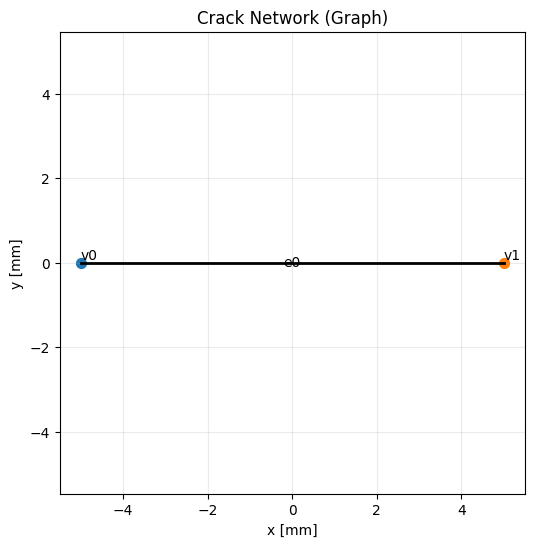

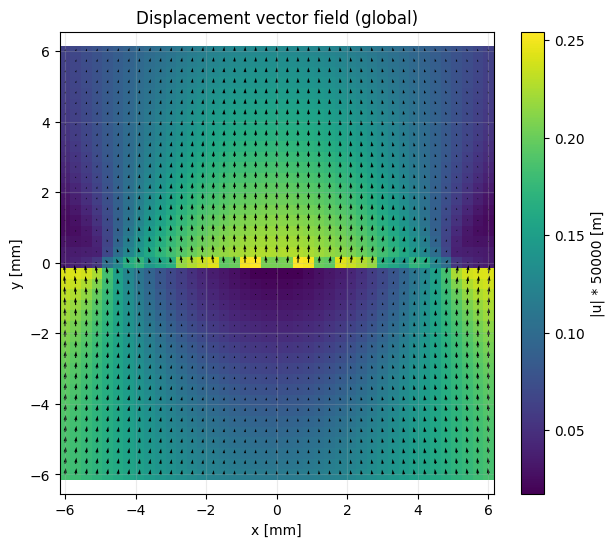

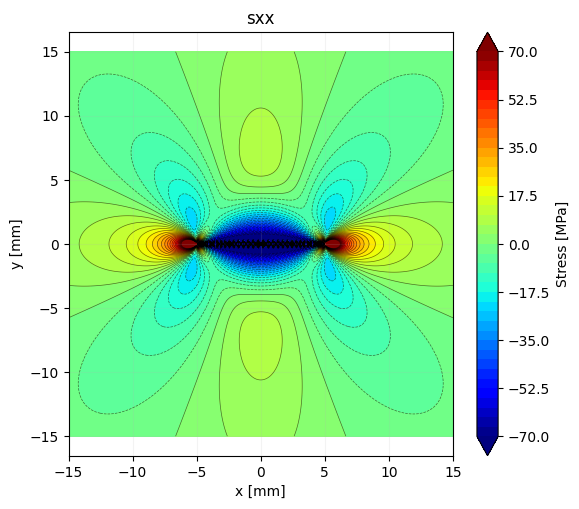

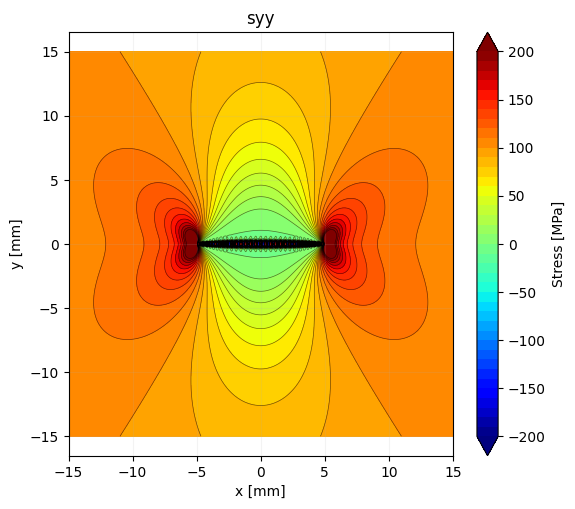

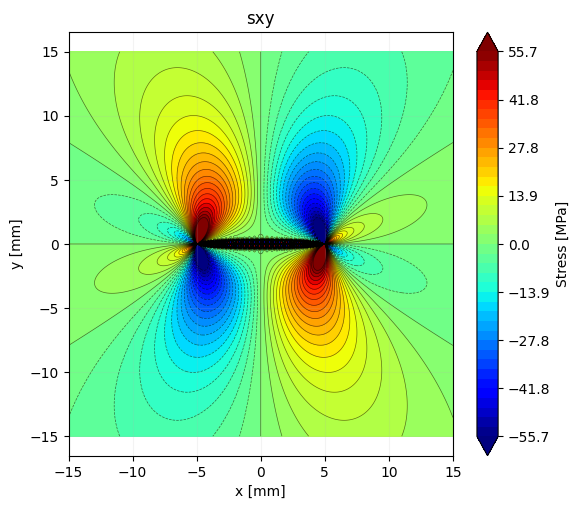

Saved figures to: /Users/ghoni/Documents/GitHub/Fracture/VCM_1_3/output/SingleHorizontalCrack


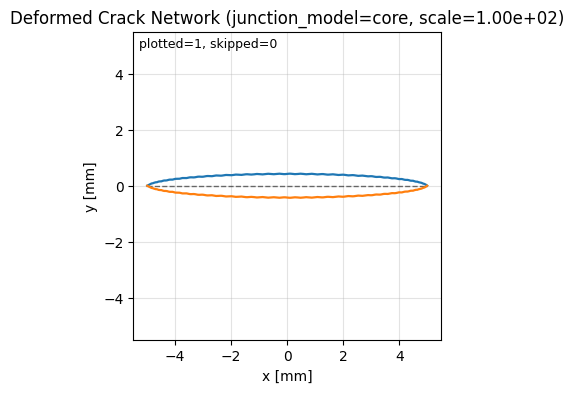

(<Figure size 650x400 with 1 Axes>,
 <Axes: title={'center': 'Deformed Crack Network (junction_model=core, scale=1.00e+02)'}, xlabel='x [mm]', ylabel='y [mm]'>)

In [ ]:
import os, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# --- repo root on sys.path (one level above notebooks/)
nb_dir = Path(os.getcwd()).resolve()
repo_root = nb_dir.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from preamble import *   
out_dir = Path(repo_root) / "output" / "SingleHorizontalCrack"
out_dir.mkdir(parents=True, exist_ok=True)


# -------------------------
# Define Y network: vertices + connectivity
# Units: meters
# -------------------------
mm = 1e-3
vertices = np.array([
    [0,   -5.0*mm,  0.0*mm],   
    [1,   5.0*mm,  0*mm], 
], dtype=float)

# edges: (edge_id, v0, v1)
connectivity = np.array([
    [0, 1],
], dtype=int)

net = CrackNetworkV4.from_vertices_connectivity(
    vertices=vertices,
    connectivity=connectivity,
    Nv_max=3,
    validate=True,
)

material = Material(E=200e9, nu=0.30, plane_stress=False)
applied  = AppliedStress(sigma_xx=0e6, sigma_yy=100e6, sigma_xy=0.0)

calc = DCENetworkStaticV4(material, net, applied)

sol  = calc.solve(
    ne_half=40,
    representation="cheb_quad",
    node_distribution="uniform",
    solver_option="parametrized_crack",
    parametrization="polyline",
    nq_col=3,
    nq_stress=6,
    crack_mode="half",
    enforce_cod_nonnegative=True,
    cod_tol=1e-10,
    cod_max_iter=25,
)


res = DCEResultsNetworkV4(calc, sol)
plotter = DCEPlotterV4(res, out_dir=out_dir)

# Graph topology
plotter.plot_network_graph()

# Displacement vector field
plotter.plot_displacement_vector_field(
    extent_factor=1.2,
    n_grid=41,
    scale=1.0,
    disp_scale=5e4,
    mask_cracks=False,
)

# Stress fields (global)
opts = StressPlotOptsV4(
    extent_factor=3,
    n_grid=400,
    add_remote=True,
    mask_cracks=False,
    cmap="jet",
    n_bands=40,
    label_contours=False,
    vmax_factor=2
)
plotter.plot_stress_components_global(opts=opts, components=("sxx","syy","sxy"))

plt.show()
print("Saved figures to:", out_dir)


# ----------------------------
# Plot: deformed network (trim junction faces; smooth COD/CSD if desired)
# ----------------------------
pl_def = DCEPlotterDeformedV4(res, out_dir=out_dir)
pl_def.plot_deformed_network(
    n_pts_per_edge=200,
    scale=1e2,
    show_faces=True,
    units="mm",
    cod_smooth_window=5,
    csd_smooth_window=5,
    junction_model="core",
)

Using repo_root = /Users/ghoni/Documents/GitHub/Fracture/VCM_1_3
fracture_utils importable = True
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Output directory exists: True
Output directory: /Users/ghoni/Documents/GitHub/Fracture/VCM_1_3/output/COD_validation


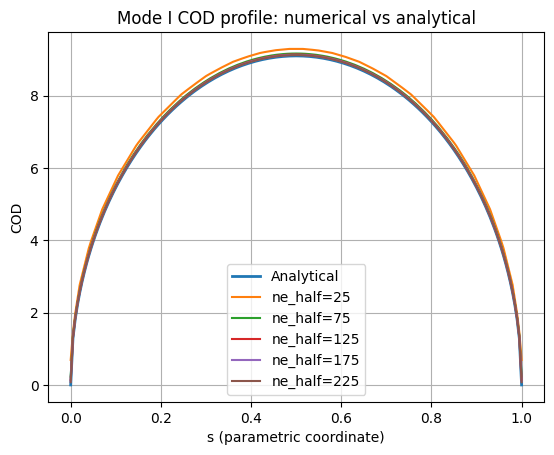

Saved: /Users/ghoni/Documents/GitHub/Fracture/VCM_1_3/output/COD_validation/cod_overlay_ne_half.png
Saved: /Users/ghoni/Documents/GitHub/Fracture/VCM_1_3/output/COD_validation/cod_combined_errors_vs_ne_half.png

All plots saved to: /Users/ghoni/Documents/GitHub/Fracture/VCM_1_3/output/COD_validation


In [ ]:
# --- COD Validation Cell (fixed calc/network wiring) ---
import os, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# --- repo root on sys.path (one level above notebooks/)
nb_dir = Path(os.getcwd()).resolve()
repo_root = nb_dir.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from preamble import *   
out_dir = Path(repo_root) / "output" / "COD_validation"
out_dir.mkdir(parents=True, exist_ok=True)
# -------------------------
# Crack/physics metadata (benchmark)
# IMPORTANT: keep 'a' consistent with the geometric half-length used below.
# -------------------------
mm = 1e-3
a_geom = 5.0 * mm  # half-length (meters)

crack_meta = dict(
    a=a_geom,
    sigma=100e6,       # magnitude used in analytical COD (Pa)
    E=200e9,
    nu=0.30,
    plane="strain",    # "strain" or "stress"
    edge_index=0,
)

# -------------------------
# Define a single straight crack network (one edge)
# Use a HORIZONTAL crack for Mode I under sigma_yy tension.
# -------------------------
vertices = np.array([
    [0, -a_geom, 0.0],   # [id, x, y]
    [1, +a_geom, 0.0],
], dtype=float)

connectivity = np.array([
    [0, 1],              # edge from v0 -> v1
], dtype=int)

network = CrackNetworkV4.from_vertices_connectivity(
    vertices=vertices,
    connectivity=connectivity,
    Nv_max=3,
    validate=True,
)

material = Material(E=crack_meta["E"], nu=crack_meta["nu"], plane_stress=("stress" in crack_meta["plane"].lower()))

# Remote loading: uniform tension in y gives Mode I for a horizontal crack
applied  = AppliedStress(sigma_xx=0.0, sigma_yy=+crack_meta["sigma"], sigma_xy=0.0)

# IMPORTANT:
#   - "network" is the geometry
#   - "calc" is the solver object that HAS calc.network, calc.material, calc.applied
calc = DCENetworkStaticV4(material=material, network=network, applied=applied)

# -------------------------
# COD solver hook for validation_cod.run_cod_sweep
# -------------------------
def run_solver_cod(knobs, crack_meta):
    """
    Return CODProfile(s, COD) for one edge using panel-midpoint reconstruction.
    COD is stored in MICRONS for plotting convenience.
    """
    sol = calc.solve(**knobs)

    # DCEResultsNetworkV4 expects (calc, sol), not (network, sol)
    res = DCEResultsNetworkV4(calc, sol)

    edge_index = int(crack_meta.get("edge_index", 0))
    x, COD, CSD, extra = res.reconstruct_cod_csd_panel_midpoints(
        edge_index=edge_index,
        enforce_global_tip_zero=True,
    )

    x = np.asarray(x, float).reshape(-1)
    COD = np.asarray(COD, float).reshape(-1) * 1e6  # Convert meters to microns
    CSD = np.asarray(CSD, float).reshape(-1)
    extra = dict(extra) if isinstance(extra, dict) else {}

    a_edge = float(extra.get("a_edge", np.max(np.abs(x))))
    s = (x + a_edge) / (2.0 * a_edge)  # map x in [-a_edge, a_edge] -> s in [0,1]

    return CODProfile(
        s=s,
        cod=COD,  # Now in microns
        meta=dict(x=x, CSD=CSD, **extra),
    )

# -------------------------
# Analytical COD: infinite plate, straight central crack under uniform tension
# delta(x) = (4*sigma/E')*sqrt(a^2 - x^2)
# Returns COD in MICRONS
# -------------------------
def analytical_cod(s, crack_meta):
    a = float(crack_meta["a"])
    sigma = float(crack_meta["sigma"])
    E = float(crack_meta["E"])
    nu = float(crack_meta["nu"])
    plane = str(crack_meta.get("plane", "strain")).lower()
    Eprime = E / (1.0 - nu**2) if "strain" in plane else E

    s = np.asarray(s, float)
    x = (2.0 * s - 1.0) * a
    cod_m = (4.0 * sigma / Eprime) * np.sqrt(np.maximum(a * a - x * x, 0.0))
    return cod_m * 1e6  # Convert meters to microns

# -------------------------
# Knob sweep
# -------------------------
ne_half_list = list(range(25, 230, 25))

knob_sweep = []
for ne in ne_half_list:
    knob_sweep.append(dict(
        ne_half=ne,
        crack_mode="full",
        representation="cheb_quad",   # or "panel", "singular", "cheb_quad"
        node_distribution="tip_dense",
        nq_col=12,
        nq_stress=16,
        ridge=1e-10,
        r0_factor=1e-3,
        solver_option="parametrized_crack",
        parametrization="polyline",
    ))

# -------------------------
# Run COD sweep
# -------------------------
sweep = run_cod_sweep(
    crack_meta=crack_meta,
    knob_sweep=knob_sweep,
    run_solver=run_solver_cod,
    analytical_cod=analytical_cod,
    s_sample=201,
)

# -------------------------
# Plot and save figures
# -------------------------

# Figure 1: COD overlay
result1 = plot_cod_overlay(
    sweep,
    knob_label_keys=("ne_half",),
    max_curves=5,
    title="Mode I COD profile: numerical vs analytical",
)
if result1 is not None:
    fig1, ax1 = result1  # Unpack the tuple
    filepath1 = out_dir / "cod_overlay_ne_half.png"
    
    # Update y-axis label to reflect microns
    ax1.set_ylabel(r"COD ($\mu$m)")
    ax1.set_xlabel("Normalized position s")  
    ax1.grid(True)
    ax1.legend()
    fig1.savefig(filepath1, dpi=300, bbox_inches='tight')
    print(f"Saved: {filepath1}")
    plt.close(fig1)

 # Figure 2: Combined L2 and Linf errors on same plot
fig2, ax2 = plt.subplots(figsize=(8, 6))

# Extract error data from sweep.results
ne_values = []
l2_errors = []
linf_errors = []

for item in sweep.results:  # Access .results attribute
    ne_values.append(item.knobs['ne_half'])  # item.knobs is a dict
    l2_errors.append(item.l2_rel_pct)        # Use attribute access
    linf_errors.append(item.linf_rel_pct)    # Use attribute access

# Plot both error metrics
ax2.plot(ne_values, l2_errors, marker='o', label=r'$L_2$ Error', linewidth=2)
ax2.plot(ne_values, linf_errors, marker='s', label=r'$L_\infty$ Error', linewidth=2)

ax2.set_xlabel('ne_half', fontsize=12)
ax2.set_ylabel('Relative Error (%)', fontsize=12)
ax2.set_title('Mode I COD Convergence: Error vs Discretization', fontsize=13)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=11)

filepath2 = out_dir / "cod_combined_errors_vs_ne_half.png"
fig2.savefig(filepath2, dpi=300, bbox_inches='tight')
print(f"Saved: {filepath2}")
plt.close(fig2)

print(f"\nAll plots saved to: {out_dir}")

Using repo_root = /Users/ghoni/Documents/GitHub/Fracture/VCM_1_3
fracture_utils importable = True
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Output directory exists: True
Output directory: /Users/ghoni/Documents/GitHub/Fracture/VCM_1_3/output/CSD_validation_ModeII


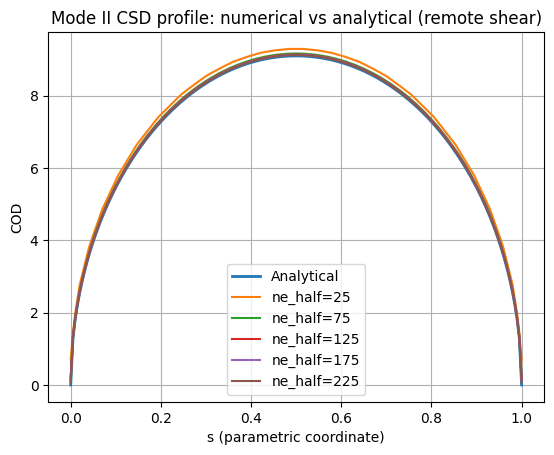

Saved: /Users/ghoni/Documents/GitHub/Fracture/VCM_1_3/output/CSD_validation_ModeII/csd_overlay_ne_half.png
Saved: /Users/ghoni/Documents/GitHub/Fracture/VCM_1_3/output/CSD_validation_ModeII/csd_combined_errors_vs_ne_half.png

All plots saved to: /Users/ghoni/Documents/GitHub/Fracture/VCM_1_3/output/CSD_validation_ModeII


In [ ]:
#### VALIDATION OF A MODE II CRACK UNDER SHEAR LOADING (CSD)

import os, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# --- repo root on sys.path (one level above notebooks/)
nb_dir = Path(os.getcwd()).resolve()
repo_root = nb_dir.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from preamble import *   
out_dir = Path(repo_root) / "output" / "CSD_validation_ModeII"
out_dir.mkdir(parents=True, exist_ok=True)

# -------------------------
# Crack/physics metadata (benchmark)
# -------------------------
mm = 1e-3
a_geom = 5.0 * mm  # half-length (m)
tau0   = 100e6      # remote shear (Pa)

crack_meta = dict(
    a=a_geom,
    tau=tau0,         # remote shear magnitude (Pa)
    E=200e9,
    nu=0.30,
    plane="strain",   # "strain" or "stress"
    edge_index=0,
)

# -------------------------
# Geometry: single horizontal crack (-a,0) -> (+a,0)
# Mode II: apply uniform remote shear sigma_xy = tau
# -------------------------
vertices = np.array([
    [0, -a_geom, 0.0],
    [1, +a_geom, 0.0],
], dtype=float)

connectivity = np.array([[0, 1]], dtype=int)

network = CrackNetworkV4.from_vertices_connectivity(
    vertices=vertices,
    connectivity=connectivity,
    Nv_max=3,
    validate=True,
)

material = Material(
    E=crack_meta["E"],
    nu=crack_meta["nu"],
    plane_stress=("stress" in crack_meta["plane"].lower()),
)

applied = AppliedStress(
    sigma_xx=0.0,
    sigma_yy=0.0,
    sigma_xy=+crack_meta["tau"],
)

calc = DCENetworkStaticV4(material=material, network=network, applied=applied)

# -------------------------
# Solver hook: return CSD profile using the CODProfile container
# -------------------------
def run_solver_csd(knobs, crack_meta):
    """
    Returns CODProfile(s, csd_um) for one edge.
    We store CSD (sliding displacement jump) in the 'cod' field for reuse of plotting utilities.
    """
    sol = calc.solve(**knobs)
    res = DCEResultsNetworkV4(calc, sol)

    edge_index = int(crack_meta.get("edge_index", 0))
    x, COD, CSD, extra = res.reconstruct_cod_csd_panel_midpoints(
        edge_index=edge_index,
        enforce_global_tip_zero=True,
    )

    x   = np.asarray(x, float).reshape(-1)
    CSD = np.asarray(CSD, float).reshape(-1) * 1e6  # meters -> microns
    extra = dict(extra) if isinstance(extra, dict) else {}

    a_edge = float(extra.get("a_edge", np.max(np.abs(x))))
    s = (x + a_edge) / (2.0 * a_edge)  # map x in [-a_edge, a_edge] -> s in [0,1]

    return CODProfile(
        s=s,
        cod=CSD,  # store CSD in microns
        meta=dict(x=x, **extra),
    )

# -------------------------
# Analytical CSD (Mode II) for infinite plate, central crack under remote shear tau
# delta_t(x) = (4*tau/E') * sqrt(a^2 - x^2)
# Returns CSD in MICRONS.
# -------------------------
def analytical_csd(s, crack_meta):
    a   = float(crack_meta["a"])
    tau = float(crack_meta["tau"])
    E   = float(crack_meta["E"])
    nu  = float(crack_meta["nu"])
    plane = str(crack_meta.get("plane", "strain")).lower()
    Eprime = E / (1.0 - nu**2) if "strain" in plane else E

    s = np.asarray(s, float)
    x = (2.0 * s - 1.0) * a
    csd_m = (4.0 * tau / Eprime) * np.sqrt(np.maximum(a*a - x*x, 0.0))
    return csd_m * 1e6  # meters -> microns

# -------------------------
# Knob sweep
# -------------------------
ne_half_list = list(range(25, 230, 25))

knob_sweep = []
for ne in ne_half_list:
    knob_sweep.append(dict(
        ne_half=int(ne),
        crack_mode="full",              # set "half" if validating half-crack formulation
        representation="cheb_quad",     # "panel", "singular", "cheb_quad", "cheb_spectral"
        node_distribution="tip_dense",
        nq_col=12,
        nq_stress=16,
        ridge=1e-10,
        r0_factor=1e-3,
        solver_option="parametrized_crack",
        parametrization="polyline",
    ))

# -------------------------
# Run sweep
# -------------------------
sweep = run_cod_sweep(
    crack_meta=crack_meta,
    knob_sweep=knob_sweep,
    run_solver=run_solver_csd,
    analytical_cod=analytical_csd,   # reuse API; returns CSD
    s_sample=201,
)

# -------------------------
# Plot and save figures
# -------------------------

# Figure 1: CSD overlay
result1 = plot_cod_overlay(
    sweep,
    knob_label_keys=("ne_half",),
    max_curves=5,
    title="Mode II CSD profile: numerical vs analytical (remote shear)",
)
if result1 is not None:
    fig1, ax1 = result1
    filepath1 = out_dir / "csd_overlay_ne_half.png"
    ax1.set_ylabel(r"CSD ($\mu$m)")
    ax1.set_xlabel("Normalized position s")
    ax1.grid(True)
    ax1.legend()
    fig1.savefig(filepath1, dpi=300, bbox_inches='tight')
    print(f"Saved: {filepath1}")
    plt.close(fig1)

# Figure 2: Combined L2 and Linf errors on same plot
fig2, ax2 = plt.subplots(figsize=(8, 6))

# Extract error data from sweep.results
ne_values = []
l2_errors = []
linf_errors = []

for item in sweep.results:  # Access .results attribute
    ne_values.append(item.knobs['ne_half'])  # item.knobs is a dict
    l2_errors.append(item.l2_rel_pct)        # Use attribute access
    linf_errors.append(item.linf_rel_pct)    # Use attribute access

# Plot both error metrics
ax2.plot(ne_values, l2_errors, marker='o', label=r'$L_2$ Error', linewidth=2)
ax2.plot(ne_values, linf_errors, marker='s', label=r'$L_\infty$ Error', linewidth=2)

ax2.set_xlabel('ne_half', fontsize=12)
ax2.set_ylabel('Relative Error (%)', fontsize=12)
ax2.set_title('Mode II CSD Convergence: Error vs Discretization', fontsize=13)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=11)

filepath2 = out_dir / "csd_combined_errors_vs_ne_half.png"
fig2.savefig(filepath2, dpi=300, bbox_inches='tight')
print(f"Saved: {filepath2}")
plt.close(fig2)

print(f"\nAll plots saved to: {out_dir}")

Using repo_root = /Users/ghoni/Documents/GitHub/Fracture/VCM_1_3
fracture_utils importable = True
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Saved: /Users/ghoni/Documents/GitHub/Fracture/VCM_1_3/output/SIF_validation/sif_error_vs_ne_half_ncol12_nsig16_linear.png
Saved: /Users/ghoni/Documents/GitHub/Fracture/VCM_1_3/output/SIF_validation/sif_error_vs_ne_half_ncol12_nsig16_log.png


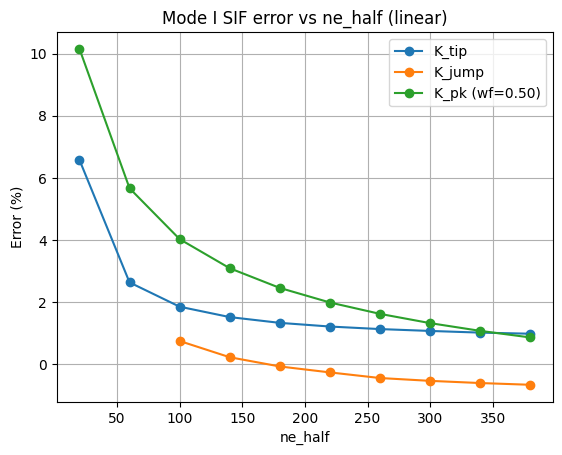

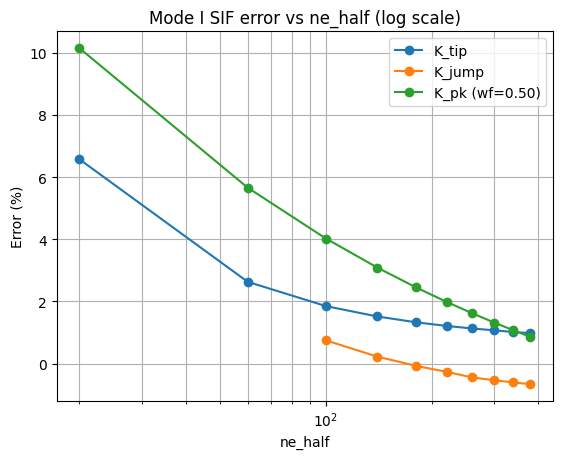

In [ ]:
# --- SIF Validation Cell (4 estimators; PK uses window_frac + normal_offset_frac sweep) ---
import os, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# --- repo root on sys.path (one level above notebooks/)
nb_dir = Path(os.getcwd()).resolve()
repo_root = nb_dir.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from preamble import *   
out_dir = Path(repo_root) / "output" / "SIF-validation"
out_dir.mkdir(parents=True, exist_ok=True)

# -------------------------
# Benchmark: straight crack, Mode I
# -------------------------
mm = 1e-3
a_geom = 5.0 * mm
sigma0 = 100e6

crack_meta = dict(
    a=a_geom,
    sigma=sigma0,
    E=200e9,
    nu=0.30,
    plane="strain",  # "strain" or "stress"
    edge_index=0,
)

# -------------------------
# Build a single-edge network
# -------------------------
vertices = np.array([
    [0, -a_geom, 0.0],
    [1, +a_geom, 0.0],
], dtype=float)

connectivity = np.array([[0, 1]], dtype=int)

network = CrackNetworkV4.from_vertices_connectivity(
    vertices=vertices,
    connectivity=connectivity,
    Nv_max=3,
    validate=True,
)

plane_stress = ("stress" in str(crack_meta["plane"]).lower())
material = Material(E=crack_meta["E"], nu=crack_meta["nu"], plane_stress=plane_stress)
applied  = AppliedStress(sigma_xx=0.0, sigma_yy=+crack_meta["sigma"], sigma_xy=0.0)
calc = DCENetworkStaticV4(material=material, network=network, applied=applied)

# -------------------------
# Analytical SIF
# -------------------------
def KI_analytic(a, sigma):
    return float(sigma * np.sqrt(np.pi * a))

# -------------------------
# Run one solve and return the 3 "good" estimators + PK (with tunables)
# -------------------------
def solve_and_estimate(ne_half: int, *, window_frac: float, normal_offset_frac: float, representation: str = "cheb_quad"):
    knobs = dict(
        ne_half=int(ne_half),
        crack_mode="half",
        representation=str(representation),
        node_distribution="tip_dense",
        nq_col=12,
        nq_stress=16,
        ridge=1e-10,
        r0_factor=1e-3,
        solver_option="parametrized_crack",
        parametrization="polyline",
    )
    sol = calc.solve(**knobs)
    res = DCEResultsNetworkV4(calc, sol)

    edge_index = int(crack_meta.get("edge_index", 0))

    x, COD, CSD, extra = res.reconstruct_cod_csd_panel_midpoints(edge_index=edge_index, enforce_global_tip_zero=True)
    extra = dict(extra) if isinstance(extra, dict) else {}
    a_fit = float(extra.get("a_edge", float(crack_meta["a"])))

    E  = float(res.calc.material.E)
    nu = float(res.calc.material.nu)
    mu = E / (2.0 * (1.0 + nu))
    plane_stress_local = bool(getattr(res.calc.material, "plane_stress", False))
    kappa  = (3.0 - nu) / (1.0 + nu) if plane_stress_local else (3.0 - 4.0 * nu)
    Eprime = E if plane_stress_local else (E / (1.0 - nu**2))

    # Tip-fit
    KI_tip, KII_tip, _ = sif_from_cod_fit(
        x=x, COD=COD, CSD=CSD,
        a=a_fit, mu=mu, kappa=kappa,
        tip="right",
        window="fixed",
        rho_min=1e-6,
        rho_max=0.80,
        min_pts=10,
        n_fit=400,
        two_term=True,
    )

    # Jump
    KI_jump, KII_jump = estimate_KI_KII_from_jumps_near_tip(
        x=x, COD=COD, CSD=CSD,
        a=a_fit,
        Eprime=Eprime,
        side="right",
        frac_window=0.08,
    )

    # PK (Mode I: KI = sqrt(E' * J1))
    pk = PKProcessor(res)
    F = pk.F_PK_window(
        edge_index=edge_index,
        at="end",
        exclude_self=True,
        window_panels=0,               # force frac-mode
        window_frac=float(window_frac),
        min_panels=12,
        normal_offset_frac=float(normal_offset_frac),
    )
    if F is None:
        KI_pk = float("nan")
        J1 = float("nan")
    else:
        # local tangent from reconstructor
        _, _, _, extra2 = res.reconstruct_cod_csd_panel_midpoints(edge_index=edge_index, enforce_global_tip_zero=False)
        extra2 = dict(extra2)
        ex = np.asarray(extra2["ex"], float).reshape(2,)
        J1 = float(np.dot(np.asarray(F, float).reshape(2,), ex))
        KI_pk = float(np.sqrt(max(E * J1, 0.0)))

    # Mode I analytic
    KI_ref = KI_analytic(a_fit, float(crack_meta["sigma"]))

    return dict(
        ne_half=int(ne_half),
        a_fit=a_fit,
        Eprime=Eprime,
        KI_ref=KI_ref,
        KI_tip=float(KI_tip),
        KI_jump=float(KI_jump),
        KI_pk=float(KI_pk),
        J1=float(J1),
    )

# -------------------------
# Sweep ne_half with a small grid of PK tunables and plot
# -------------------------
ne_half_list = list(range(20, 420, 40))

# Choose a few combinations (3–5) to avoid crowding
pk_variants = [
    # dict(window_frac=0.20, normal_offset_frac=0.0,    label="wf=0.20, off=0"),
    dict(window_frac=0.50, normal_offset_frac=5e-6, label="wf=0.50"),
]

# Precompute baseline tip/jump once per ne_half (reuse first variant result)
baseline = {}
pk_results = {v["label"]: [] for v in pk_variants}

for ne in ne_half_list:
    r0 = solve_and_estimate(ne, window_frac=pk_variants[0]["window_frac"], normal_offset_frac=pk_variants[0]["normal_offset_frac"])
    baseline[ne] = dict(KI_ref=r0["KI_ref"], KI_tip=r0["KI_tip"], KI_jump=r0["KI_jump"])

    for v in pk_variants:
        r = solve_and_estimate(ne, window_frac=v["window_frac"], normal_offset_frac=v["normal_offset_frac"])
        pk_results[v["label"]].append(r)

# -------------------------
# Plot error vs ne_half
# -------------------------
def err_pct(K, Kref):
    return 100.0 * (K - Kref) / Kref

# First figure: linear x-axis
fig1, ax1 = plt.subplots()
ax1.plot(ne_half_list, [err_pct(baseline[ne]["KI_tip"], baseline[ne]["KI_ref"]) for ne in ne_half_list],
        marker="o", label="K_tip")
ax1.plot(ne_half_list, [err_pct(baseline[ne]["KI_jump"], baseline[ne]["KI_ref"]) for ne in ne_half_list],
        marker="o", label="K_jump")
# PK variants
for lab, arr in pk_results.items():
    ax1.plot(ne_half_list, [err_pct(a["KI_pk"], a["KI_ref"]) for a in arr], marker="o", label=f"K_pk ({lab})")
ax1.set_xlabel("ne_half")
ax1.set_ylabel("Error (%)")
ax1.set_title("Mode I SIF error vs ne_half (linear)")
ax1.grid(True)
ax1.legend()
filepath1 = out_dir / 'sif_error_vs_ne_half_ncol12_nsig16_linear.png'
fig1.savefig(filepath1, dpi=300, bbox_inches='tight')
print(f"Saved: {filepath1}")

# Second figure: log x-axis
fig2, ax2 = plt.subplots()
ax2.plot(ne_half_list, [err_pct(baseline[ne]["KI_tip"], baseline[ne]["KI_ref"]) for ne in ne_half_list],
        marker="o", label="K_tip")
ax2.plot(ne_half_list, [err_pct(baseline[ne]["KI_jump"], baseline[ne]["KI_ref"]) for ne in ne_half_list],
        marker="o", label="K_jump")
# PK variants
for lab, arr in pk_results.items():
    ax2.plot(ne_half_list, [err_pct(a["KI_pk"], a["KI_ref"]) for a in arr], marker="o", label=f"K_pk ({lab})")
ax2.set_xlabel("ne_half")
ax2.set_ylabel("Error (%)")
ax2.set_title("Mode I SIF error vs ne_half (log scale)")
ax2.set_xscale('log')
ax2.grid(True, which='both')
ax2.legend()
filepath2 = out_dir / 'sif_error_vs_ne_half_ncol12_nsig16_log.png'
fig2.savefig(filepath2, dpi=300, bbox_inches='tight')
print(f"Saved: {filepath2}")

plt.show()


Using repo_root = /Users/ghoni/Documents/GitHub/Fracture/VCM_1_3
fracture_utils importable = True
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload

Solving ne_half = 20

Solving ne_half = 40

Solving ne_half = 60

Solving ne_half = 120


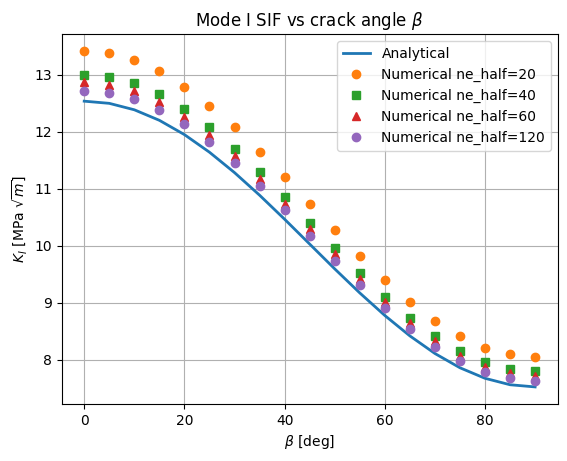

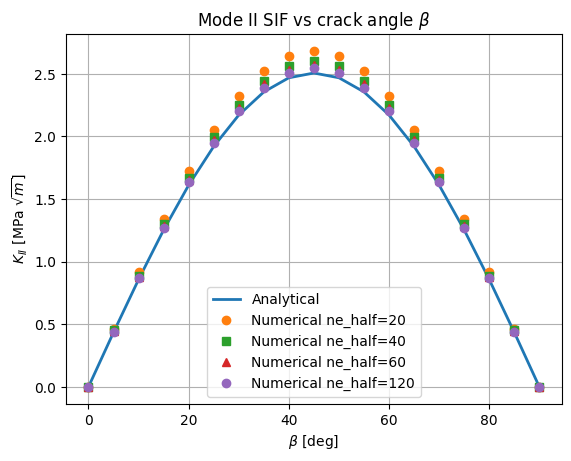


Saved plots to: /Users/ghoni/Documents/GitHub/Fracture/VCM_1_3/output/MixedMode_SIF_validation


In [ ]:
# --- Mixed-Mode SIF validation: inclined crack under biaxial loading (plots like Fig. B/C) ---
import os, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# --- repo root on sys.path (one level above notebooks/)
nb_dir = Path(os.getcwd()).resolve()
repo_root = nb_dir.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from preamble import *   
out_dir = Path(repo_root) / "output" / "MixedMode_SIF_validation"
out_dir.mkdir(parents=True, exist_ok=True)

# -------------------------
# Problem definition (match the paper figure)
# Crack length = 2a, inclined by beta from loading axis.
# Analytical (Rooke & Cartwright):
#   KI  = sqrt(pi a) ( σ22 cos^2β + σ11 sin^2β )
#   KII = sqrt(pi a) ( σ22 - σ11 ) sinβ cosβ
# -------------------------
mm = 1e-3
a = 5.0 * mm                  # half-length (m)
sig11 = 60e6                  # Pa  (σ11)
sig22 = 100e6                 # Pa  (σ22)
plane = "strain"              # "strain" or "stress"
edge_index = 0

# Sweep β in degrees (0..90)
beta_deg = np.linspace(0.0, 90.0, 19)
beta_rad = np.deg2rad(beta_deg)

# Numerical resolutions
ne_list = [20, 40, 60, 120]

# Solver knobs (common)
base_knobs = dict(
    crack_mode="full",
    representation="cheb_quad",     # you can switch to "cheb_spectral" once stable
    node_distribution="tip_dense",
    nq_col=12,
    nq_stress=16,
    ridge=1e-10,
    r0_factor=1e-3,
    solver_option="parametrized_crack",
    parametrization="polyline",
)

# -------------------------
# Helpers
# -------------------------
def analytical_K(beta):
    """Return (KI, KII) for beta (radians)."""
    KI  = np.sqrt(np.pi * a) * (sig22 * (np.cos(beta)**2) + sig11 * (np.sin(beta)**2))
    KII = np.sqrt(np.pi * a) * ((sig22 - sig11) * np.sin(beta) * np.cos(beta))
    return KI, KII

def crack_endpoints(beta):
    """Horizontal crack rotated by beta about origin."""
    c = np.cos(beta); s = np.sin(beta)
    p0 = np.array([-a, 0.0])
    p1 = np.array([+a, 0.0])
    R = np.array([[c, -s],[s, c]])
    q0 = R @ p0
    q1 = R @ p1
    return q0, q1

def solve_K_for_beta(beta, ne_half):
    """Solve for a given beta and ne_half; return (KI_tip, KII_tip)."""
    q0, q1 = crack_endpoints(beta)

    vertices = np.array([
        [0, q0[0], q0[1]],
        [1, q1[0], q1[1]],
    ], dtype=float)

    connectivity = np.array([[0, 1]], dtype=int)

    network = CrackNetworkV4.from_vertices_connectivity(
        vertices=vertices,
        connectivity=connectivity,
        Nv_max=3,
        validate=True,
    )

    material = Material(
        E=200e9,
        nu=0.30,
        plane_stress=("stress" in plane.lower()),
    )

    applied = AppliedStress(
        sigma_xx=float(sig11),
        sigma_yy=float(sig22),
        sigma_xy=0.0,
    )

    calc = DCENetworkStaticV4(material=material, network=network, applied=applied)

    knobs = dict(base_knobs)
    knobs["ne_half"] = int(ne_half)

    sol = calc.solve(**knobs)
    res = DCEResultsNetworkV4(calc, sol)

    x, COD, CSD, extra = res.reconstruct_cod_csd_panel_midpoints(
        edge_index=edge_index,
        enforce_global_tip_zero=True,
    )
    extra = dict(extra) if isinstance(extra, dict) else {}
    a_fit = float(extra.get("a_edge", a))

    # elastic constants for sif_from_cod_fit
    E  = float(res.calc.material.E)
    nu = float(res.calc.material.nu)
    mu = E / (2.0 * (1.0 + nu))
    plane_stress_local = bool(getattr(res.calc.material, "plane_stress", False))
    kappa = (3.0 - nu) / (1.0 + nu) if plane_stress_local else (3.0 - 4.0 * nu)

    KI, KII, meta = sif_from_cod_fit(
        x=x, COD=COD, CSD=CSD,
        a=a_fit,
        mu=mu,
        kappa=kappa,
        tip="right",
        window="fixed",
        rho_min=1e-6,
        rho_max=0.60,
        min_pts=10,
        n_fit=400,
        two_term=True,
    )
    return float(KI), float(KII)

# -------------------------
# Compute curves
# -------------------------
KI_ana = np.zeros_like(beta_deg, float)
KII_ana = np.zeros_like(beta_deg, float)
for i, b in enumerate(beta_rad):
    KI_ana[i], KII_ana[i] = analytical_K(b)

KI_num = {ne: np.zeros_like(beta_deg, float) for ne in ne_list}
KII_num = {ne: np.zeros_like(beta_deg, float) for ne in ne_list}

for ne in ne_list:
    print(f"\nSolving ne_half = {ne}")
    for i, b in enumerate(beta_rad):
        KI, KII = solve_K_for_beta(b, ne_half=ne)
        KI_num[ne][i] = KI
        KII_num[ne][i] = KII

# Convert to MPa*sqrt(m) for plotting
scale = 1e-6  # Pa*sqrt(m) -> MPa*sqrt(m)
KI_ana_p = KI_ana * scale
KII_ana_p = KII_ana * scale
KI_num_p = {ne: KI_num[ne] * scale for ne in ne_list}
KII_num_p = {ne: KII_num[ne] * scale for ne in ne_list}

# -------------------------
# Plot (B): KI vs beta
# -------------------------
figB, axB = plt.subplots()
axB.plot(beta_deg, KI_ana_p, label="Analytical", linewidth=2)
markers = {20:"o", 40:"s", 60:"^"}
for ne in ne_list:
    axB.plot(beta_deg, KI_num_p[ne], marker=markers.get(ne,"o"), linestyle="None", label=f"Numerical ne_half={ne}")
axB.set_xlabel(r"$\beta$ [deg]")
axB.set_ylabel(r"$K_I$ [MPa $\sqrt{m}$]")
axB.set_title(r"Mode I SIF vs crack angle $\beta$")
axB.grid(True)
axB.legend()
figB.savefig(out_dir / "KI_vs_beta.png", dpi=300, bbox_inches="tight")
plt.show()

# -------------------------
# Plot (C): KII vs beta
# -------------------------
figC, axC = plt.subplots()
axC.plot(beta_deg, KII_ana_p, label="Analytical", linewidth=2)
for ne in ne_list:
    axC.plot(beta_deg, KII_num_p[ne], marker=markers.get(ne,"o"), linestyle="None", label=f"Numerical ne_half={ne}")
axC.set_xlabel(r"$\beta$ [deg]")
axC.set_ylabel(r"$K_{II}$ [MPa $\sqrt{m}$]")
axC.set_title(r"Mode II SIF vs crack angle $\beta$")
axC.grid(True)
axC.legend()
figC.savefig(out_dir / "KII_vs_beta.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"\nSaved plots to: {out_dir}")


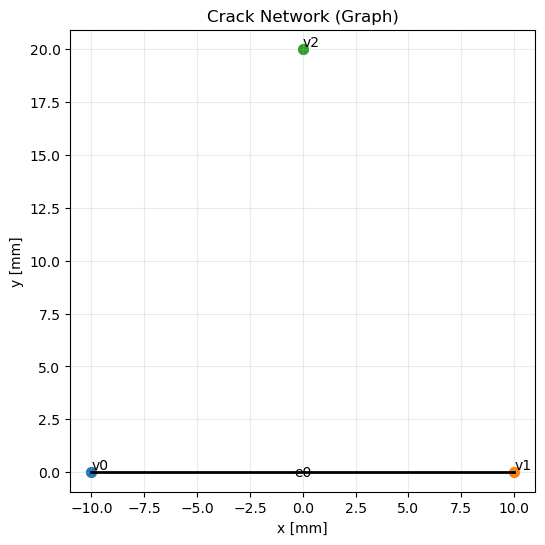

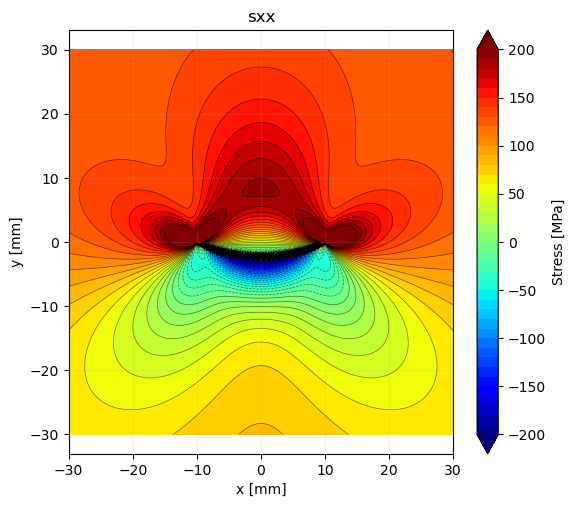

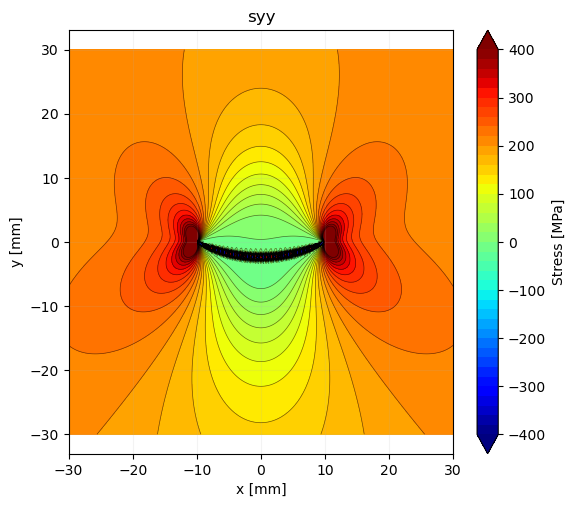

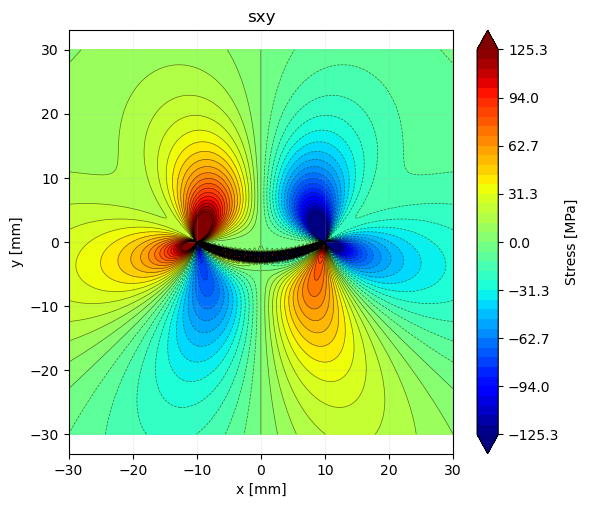

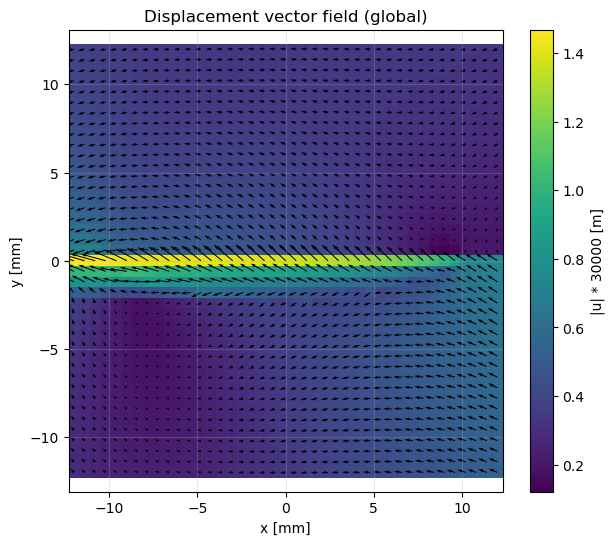

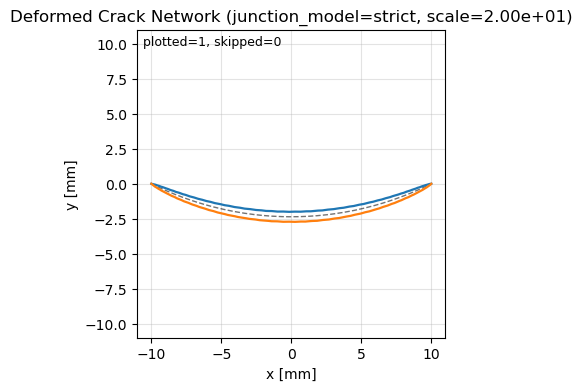

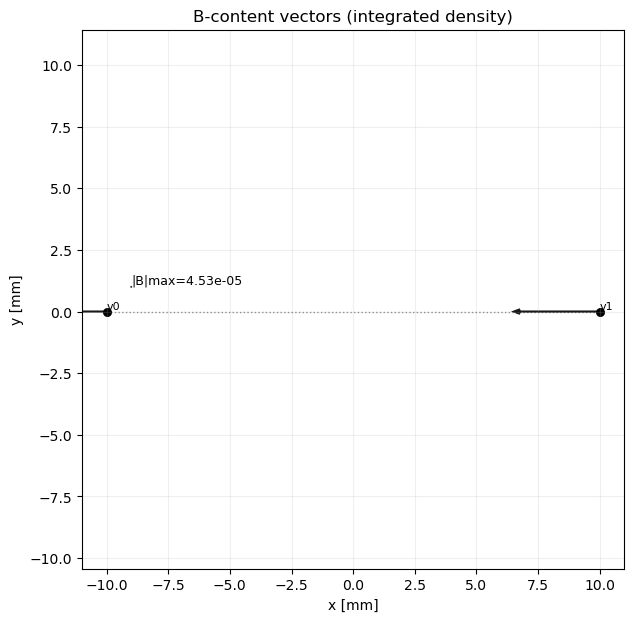

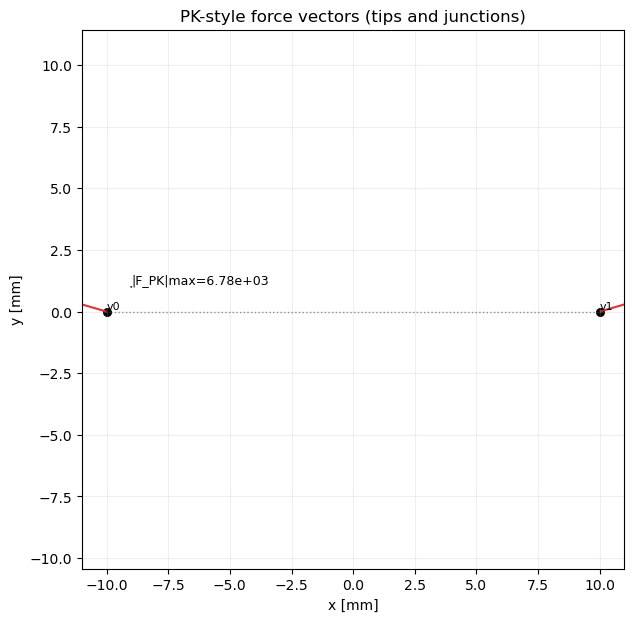

Saved figures to: C:\Users\Owner\Documents\Repos\Fracture\VCM_1_3\output\ArcField_Results


In [ ]:
import os, sys
from pathlib import Path

# Add repo root (one level above notebooks/) to sys.path
nb_dir = Path(os.getcwd()).resolve()
repo_root = nb_dir.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

# --- Preamble re-exports
from preamble import *   
out_dir = Path(repo_root) / "output" / "ArcField_Results"
out_dir.mkdir(parents=True, exist_ok=True)


# ----------------------------
# Problem definition
# ----------------------------
mm = 1e-3
a = 10.0 * mm  # crack half-length
alpha_deg = 30.0  # half arc angle in degrees
R = a / np.sin(np.deg2rad(alpha_deg))

V = np.array([
    [0, -a,    0.0],     # endpoint (node)
    [1, a,  0.0],     # endpoint (node)
    [2,  0*mm,  R],    # center (control) 
], float)

E = np.array([
    [0, 1],  
], int)


net = CrackNetworkV4.from_vertices_connectivity(
    vertices=V,
    connectivity=E,
    Nv_max=4,
    validate=True,
    edge_kinds=["arc"],      # one per edge in E, same order
    edge_ctrl_vids=[(2,)],           # one per edge; only arc gets a center
    vertex_roles={2: "control"},
)

material = Material(E=200e9, nu=0.30, plane_stress=False)
applied  = AppliedStress(sigma_xx=100.0e6, sigma_yy=200.0e6, sigma_xy=0.0)

calc = DCENetworkStaticV4(material, net, applied)
sol  = calc.solve(ne_half=40, parametrization="polyline", 
                  crack_mode="half",nq_col=12, nq_stress=16, junction_model="strict")
res = DCEResultsNetworkV4(calc, sol)

# ----------------------------
# Plot: network graph + stress + displacements
# ----------------------------
plotter = DCEPlotterV4(res, out_dir=out_dir)

_call(plotter, "plot_network_graph")

opts = StressPlotOptsV4(
    extent_factor=3,
    n_grid=301,
    add_remote=True,
    mask_cracks=False,
    cmap="jet",
    n_bands=40,
    label_contours=False,
    vmax_factor=2,
)
_call(plotter, "plot_stress_components_global", opts=opts, components=("sxx","syy","sxy"))

# If your core plotter has displacement methods, this will use them automatically.
# Otherwise, it will just skip.
_call(plotter, "plot_displacement_vector_field", disp_scale=3e4, mask_cracks=False)

# ----------------------------
# Plot: deformed network (trim junction faces; smooth COD/CSD if desired)
# ----------------------------
pl_def = DCEPlotterDeformedV4(res, out_dir=out_dir)
pl_def.plot_deformed_network(
    n_pts_per_edge=200,
    scale=2e1,
    show_faces=True,
    units="mm",
    junction_model="strict",
)

# ----------------------------
# Vectors: B-content and PK forces
# ----------------------------
pkplt = DCEPlotterPK(res, out_dir=out_dir)

_call(
    pkplt,
    "plot_b_content_vectors",
    style=VecPlotStyle(max_len_factor=0.18),
    user_scale=1e-3,
    units="mm",
    show_tips=True,
    show_junctions=True,
    show_sum_at_junction=True,
    annotate=True,
)

_call(
    pkplt,
    "plot_pk_force_vectors",
    style=VecPlotStyle(max_len_factor=0.18),
    user_scale=1e-3,
    units="mm",
    exclude_self=True,
    show_tips=True,
    show_junctions=True,
    n_samples_tip=32,
    annotate=True,
)

plt.show()
print("Saved figures to:", out_dir)


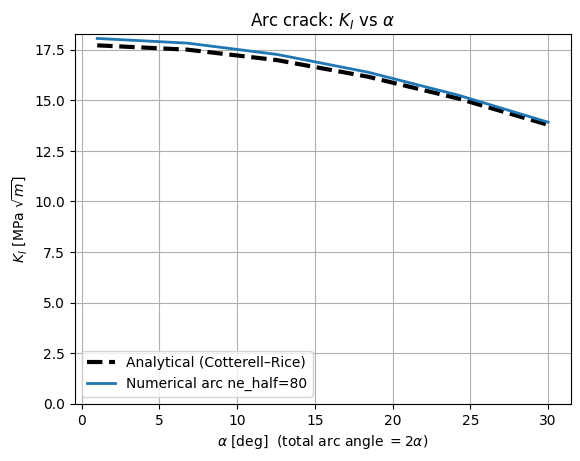

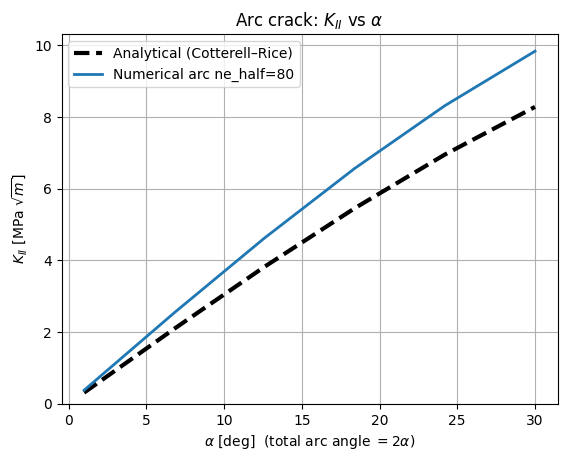

In [1]:
# ============================================================
# Cotterell–Rice (IJF 1980) validation for circular arc crack
# ============================================================

import os, sys
from pathlib import Path

# Add repo root (one level above notebooks/) to sys.path
nb_dir = Path(os.getcwd()).resolve()
repo_root = nb_dir.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

# --- Preamble re-exports
from preamble import *   
out_dir = Path(repo_root) / "output" / "Arc_CotterellRice_Validation"
out_dir.mkdir(parents=True, exist_ok=True)

# -------------------------
# Problem inputs
# -------------------------
mm = 1e-3
a_chord = 10.0 * mm     # HALF chord length
E = 200e9
nu = 0.30
plane = "strain"
edge_index = 0

sig_xx = 0e6
sig_yy = 100e6
sig_xy = 0.0

# alpha = half-angle; total arc angle = 2*alpha
alpha_deg = np.linspace(1.0, 30.0, 6)
alpha = np.deg2rad(alpha_deg)

# solver knobs
base_knobs = dict(
    crack_mode="half",
    representation="cheb_quad",
    node_distribution="tip_dense",
    nq_col=12,
    nq_stress=16,
    ridge=1e-10,
    r0_factor=1e-3,
    solver_option="parametrized_crack",
    junction_model="strict",
    parametrization="polyline",
)
# -------------------------
# Arc geometry (TRUE circle center)
# -------------------------
def arc_network(alpha):
    R = a_chord / np.sin(alpha)
    y_c = R * np.cos(alpha)     # TRUE center

    V = np.array([
        [0, -a_chord, 0.0],
        [1,  a_chord, 0.0],
        [2,  0.0,     y_c],     # CONTROL = CENTER
    ], float)

    E = np.array([[0, 1]], int)

    return CrackNetworkV4.from_vertices_connectivity(
        vertices=V,
        connectivity=E,
        Nv_max=4,
        validate=True,
        edge_kinds=["arc"],
        edge_ctrl_vids=[(2,)],
        vertex_roles={2: "control"},
    )

# -------------------------
# Solver wrapper
# -------------------------
def solve_K(net, ne_half):
    material = Material(E=E, nu=nu, plane_stress=("stress" in plane))
    applied  = AppliedStress(sig_xx, sig_yy, sig_xy)

    calc = DCENetworkStaticV4(material, net, applied)
    knobs = dict(base_knobs)
    knobs["ne_half"] = int(ne_half)

    sol = calc.solve(**knobs)
    res = DCEResultsNetworkV4(calc, sol)

    x, COD, CSD, extra = res.reconstruct_cod_csd_panel_midpoints(
        edge_index=edge_index,
        enforce_global_tip_zero=True,
    )

    a_arc = float(extra["a_edge"])  # HALF ARC LENGTH

    mu = E / (2.0 * (1.0 + nu))
    kappa = (3.0 - 4.0 * nu)

    KI, KII, _ = sif_from_cod_fit(
        x=x, COD=COD, CSD=CSD,
        a=a_arc,
        mu=mu,
        kappa=kappa,
        tip="right",
        window="fixed",
        rho_min=1e-6,
        rho_max=0.06,
        min_pts=10,
        n_fit=400,
        two_term=False,
    )

    return float(KI), float(KII), a_arc


# ============================================================
# Run: ARC geometry, ne_half = 80
# ============================================================
ne_half = 80
scale = 1e-6

KI_num = []
KII_num = []
KI_ana = []
KII_ana = []

for al in alpha:
    R = a_chord / np.sin(al)
    a_arc = R * al

    KIa, KIIa = cotterell_rice_K(al, a_chord, sig_xx, sig_yy, sig_xy)
    KI_ana.append(KIa)
    KII_ana.append(KIIa)

    net = arc_network(al)
    KIn, KIIn, _ = solve_K(net, ne_half)
    KI_rn, KII_rn = rotate_sifs(KIn, KIIn, -2*al)

    KI_num.append(KI_rn)
    KII_num.append(KII_rn)
    
KI_ana = np.array(KI_ana)
KII_ana = np.array(KII_ana)
KI_num = np.array(KI_num)
KII_num = np.array(KII_num)


# -------------------------
# Plots
# -------------------------
fig1, ax1 = plt.subplots()
ax1.plot(alpha_deg, KI_ana*scale, "k--", lw=3, label="Analytical (Cotterell–Rice)")
ax1.plot(alpha_deg, KI_num*scale, lw=2, label=f"Numerical arc ne_half={ne_half}")
ax1.set_xlabel(r"$\alpha$ [deg]  (total arc angle $=2\alpha$)")
ax1.set_ylabel(r"$K_I$ [MPa $\sqrt{m}$]")
ax1.set_title("Arc crack: $K_I$ vs $\\alpha$")
ax1.grid(True); ax1.legend()
ax1.set_ylim(bottom=0)
fig1.savefig(out_dir / "KI_vs_alpha_1term_ne80.png", dpi=300, bbox_inches="tight")
plt.show()

fig2, ax2 = plt.subplots()
ax2.plot(alpha_deg, KII_ana*scale, "k--", lw=3, label="Analytical (Cotterell–Rice)")
ax2.plot(alpha_deg,KII_num*scale, lw=2, label=f"Numerical arc ne_half={ne_half}")
ax2.set_xlabel(r"$\alpha$ [deg]  (total arc angle $=2\alpha$)")
ax2.set_ylabel(r"$K_{II}$ [MPa $\sqrt{m}$]")
ax2.set_title("Arc crack: $K_{II}$ vs $\\alpha$")
ax2.grid(True); ax2.legend()
ax2.set_ylim(bottom=0)
fig2.savefig(out_dir / "KII_vs_alpha_1term_ne80.png", dpi=300, bbox_inches="tight")
plt.show()



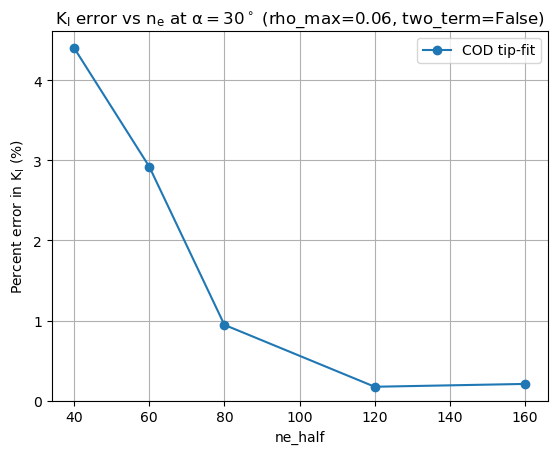

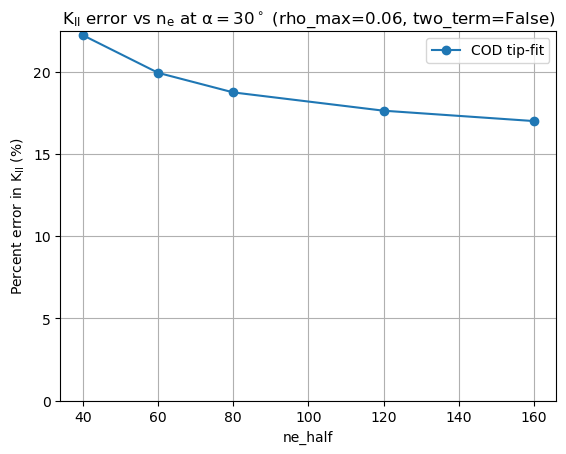


Analytical at alpha=30deg (total angle=60deg):
  KI  = 13.788006363157935 MPa*sqrt(m)
  KII = 8.281933302039864 MPa*sqrt(m)
Saved plots to: C:\Users\Owner\Documents\Repos\Fracture\VCM_1_3\output\Arc_CotterellRice_Validation


In [4]:
# ============================================================
# Arc crack @ alpha=30deg: percent error vs ne_half
# Estimators: (1) COD tip-fit, (2) PK-based SIF estimator
# ============================================================

import os, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# --- repo root on sys.path (one level above notebooks/)
nb_dir = Path(os.getcwd()).resolve()
repo_root = nb_dir.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from preamble import *   
out_dir = Path(repo_root) / "output" / "Arc_CotterellRice_Validation"
out_dir.mkdir(parents=True, exist_ok=True)
# -------------------------
# Fixed problem inputs
# -------------------------
mm = 1e-3
a_chord = 10.0 * mm
E = 200e9
nu = 0.30
plane = "strain"
edge_index = 0

sig_xx = 0e6
sig_yy = 100e6
sig_xy = 0.0

alpha_deg = 30.0
alpha = np.deg2rad(alpha_deg)

# --- sweep ne_half
ne_half_list = [40, 60, 80, 120, 160]

# -------------------------
# Fit/PK settings (FIXED)
# -------------------------
rho_min = 1e-6
rho_max = 0.06
two_term = False         # set True for 2-term
n_fit = 400
min_pts = 10

# PK settings (fixed)
pk_window_panels = 12
pk_window_frac = 0.3
pk_exclude_self = True
pk_plane_strain = True

# -------------------------
# Solver knobs (fixed)
# -------------------------
base_knobs = dict(
    crack_mode="half",
    representation="cheb_quad",
    node_distribution="tip_dense",
    nq_col=12,
    nq_stress=16,
    ridge=1e-10,
    r0_factor=1e-3,
    solver_option="parametrized_crack",
    junction_model="strict",
    parametrization="polyline",
)

# -------------------------
# Arc geometry: control is circle center
# -------------------------
def arc_network(alpha_half):
    R = a_chord / np.sin(alpha_half)
    y_c = R * np.cos(alpha_half)

    V = np.array([
        [0, -a_chord, 0.0],
        [1,  a_chord, 0.0],
        [2,  0.0,     y_c],   # center
    ], float)

    Econn = np.array([[0, 1]], int)

    return CrackNetworkV4.from_vertices_connectivity(
        vertices=V,
        connectivity=Econn,
        Nv_max=4,
        validate=True,
        edge_kinds=["arc"],
        edge_ctrl_vids=[(2,)],
        vertex_roles={2: "control"},
    )

# -------------------------
# Solve once per ne_half and compute both estimators
# -------------------------
def solve_estimators(ne_half):
    material = Material(E=E, nu=nu, plane_stress=("stress" in plane))
    applied  = AppliedStress(sig_xx, sig_yy, sig_xy)

    net = arc_network(alpha)
    calc = DCENetworkStaticV4(material, net, applied)

    knobs = dict(base_knobs)
    knobs["ne_half"] = int(ne_half)

    sol = calc.solve(**knobs)
    res = DCEResultsNetworkV4(calc, sol)

    x, COD, CSD, extra = res.reconstruct_cod_csd_panel_midpoints(
        edge_index=edge_index,
        enforce_global_tip_zero=True,
    )
    extra = dict(extra) if isinstance(extra, dict) else {}
    a_arc = float(extra["a_edge"])

    # elastic constants for COD fit
    mu = E / (2.0 * (1.0 + nu))
    kappa = (3.0 - 4.0 * nu) if ("strain" in plane.lower()) else (3.0 - nu) / (1.0 + nu)

    # (1) COD tip-fit estimator
    KI_cod, KII_cod, _meta = sif_from_cod_fit(
        x=x, COD=COD, CSD=CSD,
        a=a_arc,
        mu=mu,
        kappa=kappa,
        tip="right",
        window="fixed",
        rho_min=rho_min,
        rho_max=rho_max,
        min_pts=min_pts,
        n_fit=n_fit,
        two_term=two_term,
    )

    # (2) PK estimator
    pk = PKProcessor(res)
    KI_pk, KII_pk, meta_pk = pk_sif_from_window(
    pk,
    edge_index=edge_index,
    at="end",
    window_panels=pk_window_panels,
    window_frac=pk_window_frac,
    exclude_self=True,
    plane_strain=True,
    theta_rot=-2.0*alpha,   # <- use 0.0 if you want “solver/global” frame
    )

    # rotate numerical results into Cotterell–Rice comparison frame (your convention)
    theta_rot = -2.0 * alpha
    KI_cod_r, KII_cod_r = rotate_sifs(float(KI_cod), float(KII_cod), theta_rot)
    KI_pk_r,  KII_pk_r  = rotate_sifs(float(KI_pk),  float(KII_pk),  theta_rot)

    return a_arc, KI_cod_r, KII_cod_r, KI_pk_r, KII_pk_r

# -------------------------
# Analytical at alpha=30deg (total angle = 2*alpha)
# -------------------------
R = a_chord / np.sin(alpha)
a_arc_true = R * alpha
KI_a, KII_a = cotterell_rice_K(alpha, a_chord, sig_xx, sig_yy, sig_xy)

# -------------------------
# Sweep
# -------------------------
KI_err_cod, KII_err_cod, KI_err_pk, KII_err_pk = [], [], [], []

for ne in ne_half_list:
    a_arc, KIc, KIIc, KIp, KIIp = solve_estimators(ne)

    KI_err_cod.append(100.0 * abs((KIc - KI_a) / (KI_a if KI_a != 0 else 1.0)))
    KII_err_cod.append(100.0 * abs((KIIc - KII_a) / (KII_a if KII_a != 0 else 1.0)))

    KI_err_pk.append(100.0 * abs((KIp - KI_a) / (KI_a if KI_a != 0 else 1.0)))
    KII_err_pk.append(100.0 * abs((KIIp - KII_a) / (KII_a if KII_a != 0 else 1.0)))

KI_err_cod = np.array(KI_err_cod)
KII_err_cod = np.array(KII_err_cod)
KI_err_pk = np.array(KI_err_pk)
KII_err_pk = np.array(KII_err_pk)

# -------------------------
# Plots
# -------------------------
fig1, ax1 = plt.subplots()
ax1.plot(ne_half_list, KI_err_cod, "o-", label="COD tip-fit")
# ax1.plot(ne_half_list, KI_err_pk,  "s--", label="PK estimator")
ax1.set_xlabel("ne_half")
ax1.set_ylabel("Percent error in $K_I$ (%)")
ax1.set_title(rf"$K_I$ error vs $n_e$ at $\alpha=30^\circ$ (rho_max={rho_max}, two_term={two_term})")
ax1.grid(True); ax1.legend()
fig1.savefig(out_dir / "KI_error_vs_ne_half_alpha30.png", dpi=300, bbox_inches="tight")
ax1.set_ylim(bottom=0)
plt.show()

fig2, ax2 = plt.subplots()
ax2.plot(ne_half_list, KII_err_cod, "o-", label="COD tip-fit")
# ax2.plot(ne_half_list, KII_err_pk,  "s--", label="PK estimator")
ax2.set_xlabel("ne_half")
ax2.set_ylabel("Percent error in $K_{II}$ (%)")
ax2.set_title(rf"$K_{{II}}$ error vs $n_e$ at $\alpha=30^\circ$ (rho_max={rho_max}, two_term={two_term})")
ax2.grid(True); ax2.legend()
fig2.savefig(out_dir / "KII_error_vs_ne_half_alpha30.png", dpi=300, bbox_inches="tight")
ax2.set_ylim(bottom=0)
plt.show()

print("\nAnalytical at alpha=30deg (total angle=60deg):")
print("  KI  =", KI_a*1e-6, "MPa*sqrt(m)")
print("  KII =", KII_a*1e-6, "MPa*sqrt(m)")
print("Saved plots to:", out_dir)


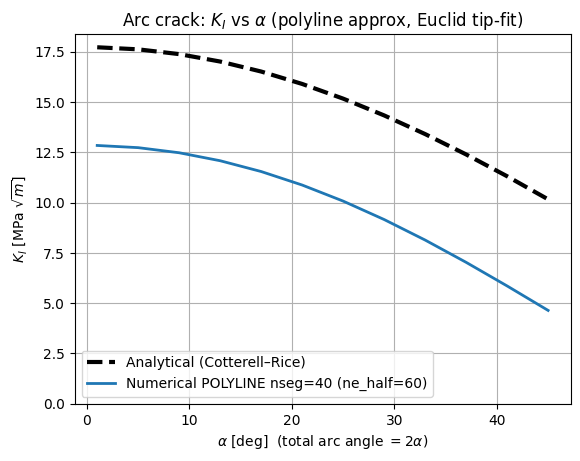

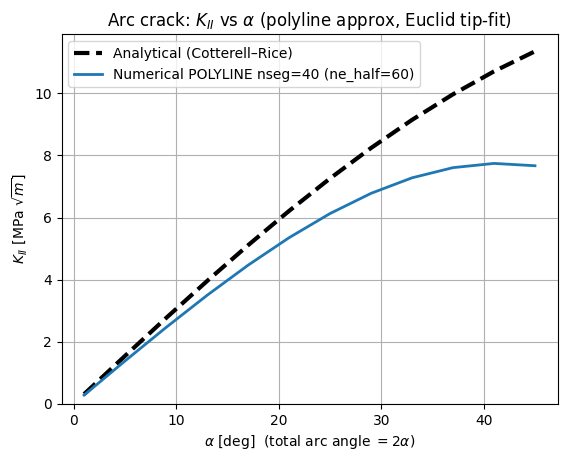

In [5]:
# ============================================================
# Cotterell–Rice validation for circular arc crack using a POLYLINE approximation
# Robust Euclidean tip-fit: use p_tip from constructed V (no net.vertices slicing)
# ============================================================

import os, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Add repo root (one level above notebooks/) to sys.path
nb_dir = Path(os.getcwd()).resolve()
repo_root = nb_dir.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from preamble import *
out_dir = Path(repo_root) / "output" / "ArcPolyline_CotterellRice_Validation"
out_dir.mkdir(parents=True, exist_ok=True)
import inspect
from fracture_utils.Uprocessor import SIF as sifmod

# -------------------------
# Inputs
# -------------------------
mm = 1e-3
a_chord = 10.0 * mm
E = 200e9
nu = 0.30
plane = "strain"

sig_xx = 0e6
sig_yy = 100e6
sig_xy = 0.0

alpha_deg = np.linspace(1.0, 45.0, 12)
alpha = np.deg2rad(alpha_deg)

ne_half = 60
nseg_test = 40
edge_tip = nseg_test - 1
scale = 1e-6

base_knobs = dict(
    crack_mode="half",
    representation="cheb_quad",
    node_distribution="tip_dense",
    nq_col=12,
    nq_stress=16,
    ridge=1e-10,
    r0_factor=1e-3,
    solver_option="parametrized_crack",
    junction_model="strict",
    parametrization="polyline",
)

KI_ana, KII_ana = [], []
KI_poly, KII_poly = [], []

for al in alpha:
    R = a_chord / np.sin(al)
    a_fit_global = R * al  # half arc length

    KIa, KIIa = cotterell_rice_K(al, a_fit_global, sig_xx, sig_yy, sig_xy)
    KI_ana.append(KIa); KII_ana.append(KIIa)

    net, V = polyline_arc_network(al, a_chord, nseg=nseg_test)

    KI_loc, KII_loc, KI_CR, KII_CR, meta = solve_K_polyline(
        net, V, ne_half, edge_tip, a_fit_global,
        E=E, nu=nu, plane=plane,
        sig_xx=sig_xx, sig_yy=sig_yy, sig_xy=sig_xy,
        base_knobs=base_knobs,
        fit_frac=0.3,
        min_segs=4,
        rmax_frac=0.05,
        two_term=False,
        )
    if KII_CR < 0.0:
        KII_CR = -KII_CR

    KI_poly.append(KI_CR)
    KII_poly.append(KII_CR)

KI_ana = np.array(KI_ana); KII_ana = np.array(KII_ana)
KI_poly = np.array(KI_poly); KII_poly = np.array(KII_poly)

# -------------------------
# Plots
# -------------------------
fig1, ax1 = plt.subplots()
ax1.plot(alpha_deg, KI_ana*scale, "k--", lw=3, label="Analytical (Cotterell–Rice)")
ax1.plot(alpha_deg, KI_poly*scale, lw=2, label=f"Numerical POLYLINE nseg={nseg_test} (ne_half={ne_half})")
ax1.set_xlabel(r"$\alpha$ [deg]  (total arc angle $=2\alpha$)")
ax1.set_ylabel(r"$K_I$ [MPa $\sqrt{m}$]")
ax1.set_title("Arc crack: $K_I$ vs $\\alpha$ (polyline approx, Euclid tip-fit)")
ax1.grid(True); ax1.legend()
ax1.set_ylim(bottom=0)
fig1.savefig(out_dir / "K_I_vs_alpha_polyline_ne60_nseg40.png", dpi=300, bbox_inches="tight")
plt.show()

fig2, ax2 = plt.subplots()
ax2.plot(alpha_deg, KII_ana*scale, "k--", lw=3, label="Analytical (Cotterell–Rice)")
ax2.plot(alpha_deg, KII_poly*scale, lw=2, label=f"Numerical POLYLINE nseg={nseg_test} (ne_half={ne_half})")
ax2.set_xlabel(r"$\alpha$ [deg]  (total arc angle $=2\alpha$)")
ax2.set_ylabel(r"$K_{II}$ [MPa $\sqrt{m}$]")
ax2.set_title("Arc crack: $K_{II}$ vs $\\alpha$ (polyline approx, Euclid tip-fit)")
ax2.grid(True); ax2.legend()
ax2.set_ylim(bottom=0)
fig2.savefig(out_dir / "K_II_vs_alpha_polyline_ne60_nseg40.png", dpi=300, bbox_inches="tight")
plt.show()

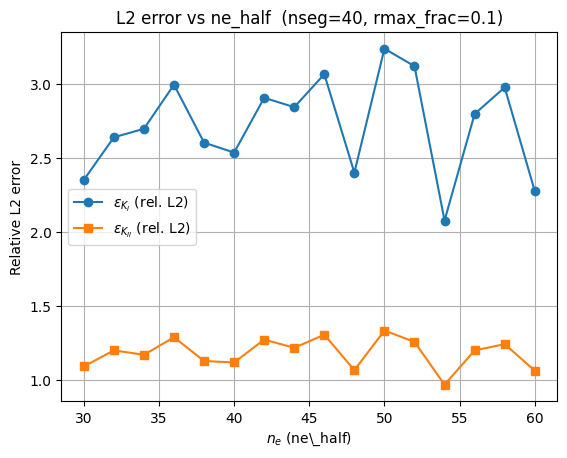

In [6]:
# ============================================================
# Diagnostics: L2 error vs ne_half and vs rmax_frac
# ============================================================

def compute_K_arrays(ne_half_val, rmax_frac_val, *, fit_frac, min_segs, two_term):
    KI_ana, KII_ana = [], []
    KI_num, KII_num = [], []

    for al in alpha:
        R = a_chord / np.sin(al)
        a_fit_global = R * al  # half arc length

        KIa, KIIa = cotterell_rice_K(al, a_fit_global, sig_xx, sig_yy, sig_xy)
        KI_ana.append(KIa); KII_ana.append(KIIa)

        net, V = polyline_arc_network(al, a_chord, nseg=nseg_test)

        KI_loc, KII_loc, KI_CR, KII_CR, meta = solve_K_polyline(
            net, V, int(ne_half_val), edge_tip, a_fit_global,
            E=E, nu=nu, plane=plane,
            sig_xx=sig_xx, sig_yy=sig_yy, sig_xy=sig_xy,
            base_knobs=base_knobs,
            fit_frac=float(fit_frac),
            min_segs=int(min_segs),
            rmax_frac=float(rmax_frac_val),
            two_term=bool(two_term),
        )

        # keep your convention (KII positive)
        if KII_CR < 0.0:
            KII_CR = -KII_CR

        KI_num.append(KI_CR)
        KII_num.append(KII_CR)

    KI_ana = np.asarray(KI_ana, float)
    KII_ana = np.asarray(KII_ana, float)
    KI_num = np.asarray(KI_num, float)
    KII_num = np.asarray(KII_num, float)
    return KI_ana, KII_ana, KI_num, KII_num


def rel_L2(num, ana):
    num = np.asarray(num, float)
    ana = np.asarray(ana, float)
    denom = np.linalg.norm(ana)
    if denom == 0:
        return np.nan
    return np.linalg.norm(num - ana) / denom


# -------------------------
# (1) L2 error vs ne_half
# -------------------------
ne_list = np.arange(30, 61, 2)  # 2..40 in steps of 2 (change if you want every integer)
errKI_ne = []
errKII_ne = []

# Use the SAME knobs you currently used in the main loop
fit_frac_fixed = 0.3
min_segs_fixed = 4
rmax_fixed = 0.1
two_term_fixed = False

for ne_val in ne_list:
    KIa, KIIa, KIn, KIIn = compute_K_arrays(
        ne_val, rmax_fixed,
        fit_frac=fit_frac_fixed,
        min_segs=min_segs_fixed,
        two_term=two_term_fixed
    )
    errKI_ne.append(rel_L2(KIn, KIa))
    errKII_ne.append(rel_L2(KIIn, KIIa))

errKI_ne = np.asarray(errKI_ne, float)
errKII_ne = np.asarray(errKII_ne, float)

fig, ax = plt.subplots()
ax.plot(ne_list, errKI_ne, "o-", label=r"$\epsilon_{K_I}$ (rel. L2)")
ax.plot(ne_list, errKII_ne, "s-", label=r"$\epsilon_{K_{II}}$ (rel. L2)")
ax.set_xlabel(r"$n_e$ (ne\_half)")
ax.set_ylabel("Relative L2 error")
ax.set_title(f"L2 error vs ne_half  (nseg={nseg_test}, rmax_frac={rmax_fixed})")
ax.grid(True)
ax.legend()
fig.savefig(out_dir / f"L2_error_vs_ne_half_nseg{nseg_test}_rmax{rmax_fixed}.png", dpi=300, bbox_inches="tight")
plt.show()



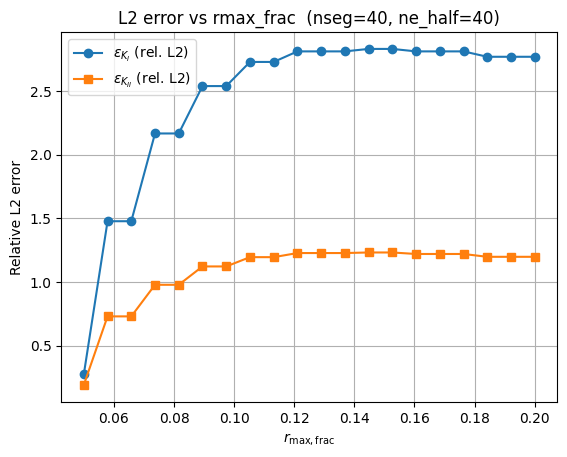

In [7]:

# -------------------------
# (2) L2 error vs rmax_frac
# -------------------------
rmax_list = np.linspace(0.05, 0.20, 20)
errKI_r = []
errKII_r = []

ne_fixed = 40  # per your request

for rmax_val in rmax_list:
    KIa, KIIa, KIn, KIIn = compute_K_arrays(
        ne_fixed, rmax_val,
        fit_frac=fit_frac_fixed,
        min_segs=min_segs_fixed,
        two_term=two_term_fixed
    )
    errKI_r.append(rel_L2(KIn, KIa))
    errKII_r.append(rel_L2(KIIn, KIIa))

errKI_r = np.asarray(errKI_r, float)
errKII_r = np.asarray(errKII_r, float)

fig, ax = plt.subplots()
ax.plot(rmax_list, errKI_r, "o-", label=r"$\epsilon_{K_I}$ (rel. L2)")
ax.plot(rmax_list, errKII_r, "s-", label=r"$\epsilon_{K_{II}}$ (rel. L2)")
ax.set_xlabel(r"$r_{\max,\mathrm{frac}}$")
ax.set_ylabel("Relative L2 error")
ax.set_title(f"L2 error vs rmax_frac  (nseg={nseg_test}, ne_half={ne_fixed})")
ax.grid(True)
ax.legend()
fig.savefig(out_dir / f"L2_error_vs_rmax_nseg{nseg_test}_ne{ne_fixed}.png", dpi=300, bbox_inches="tight")
plt.show()


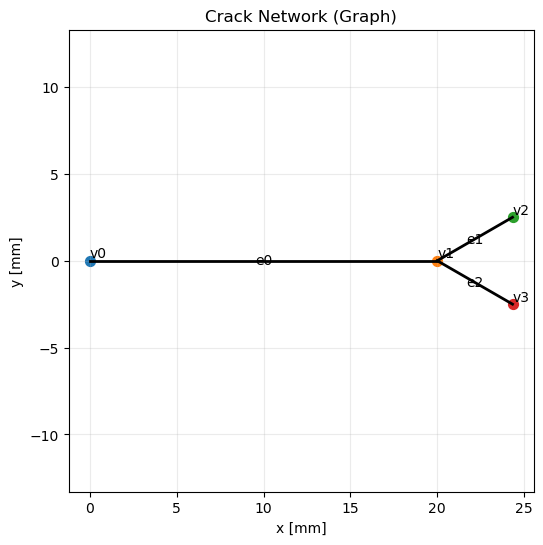

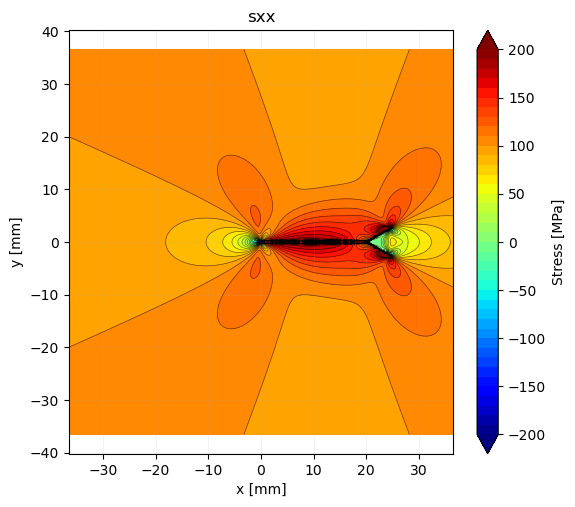

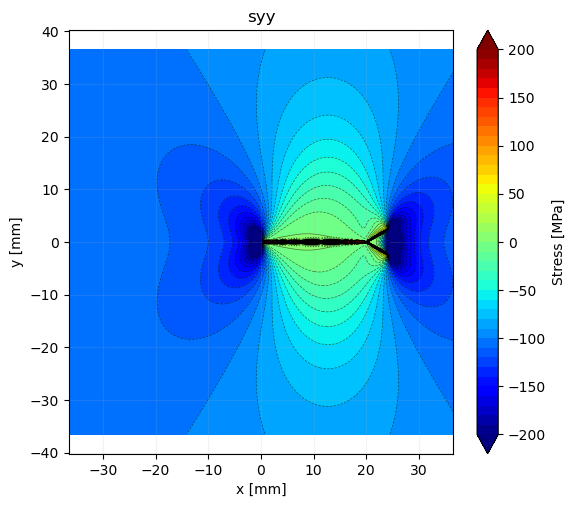

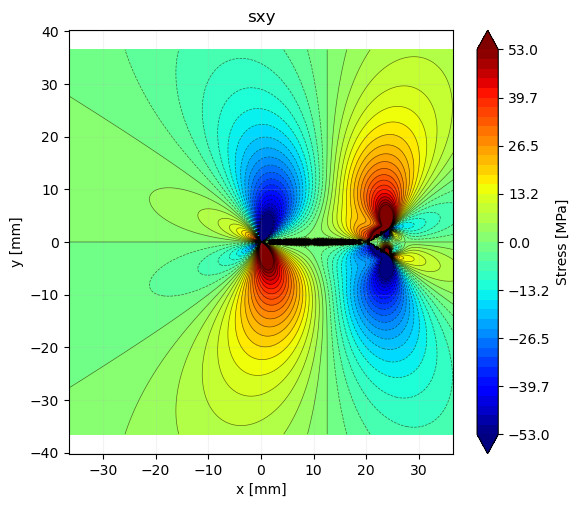

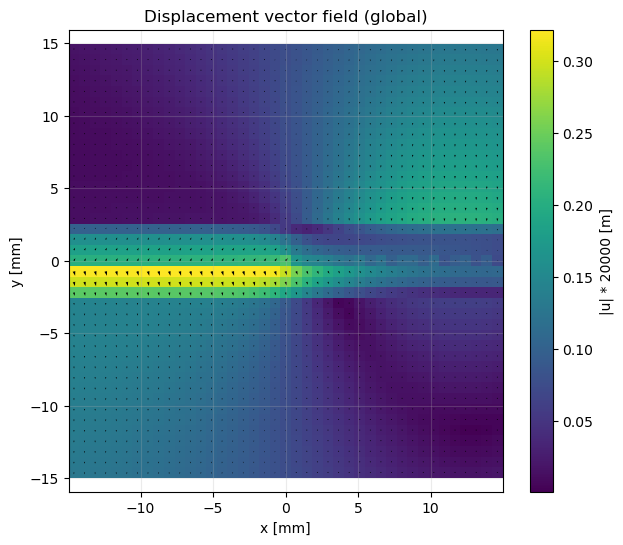

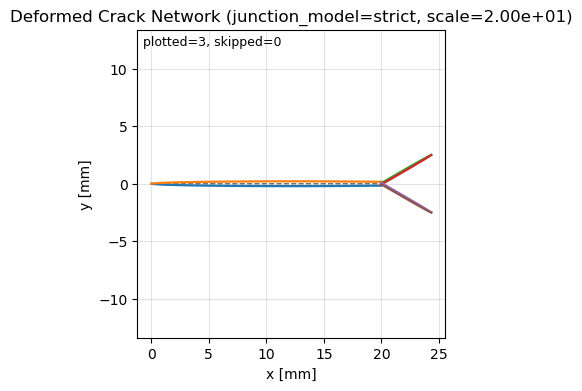

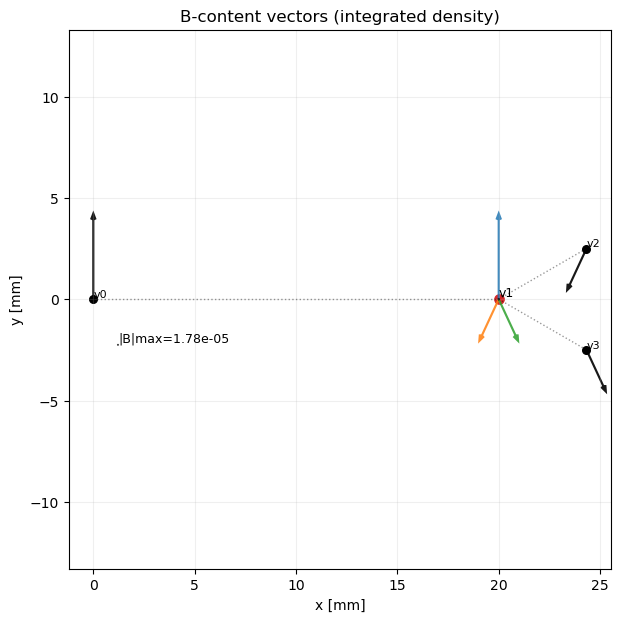

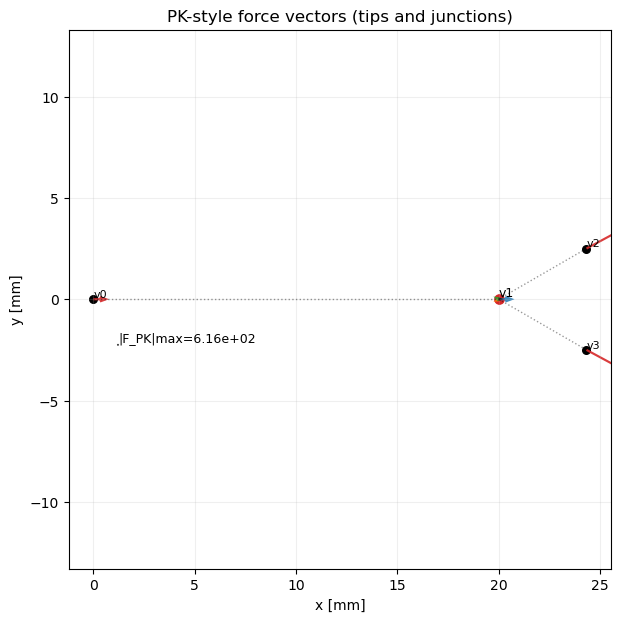

Saved figures to: C:\Users\Owner\Documents\Repos\Fracture\VCM_1_3\output\Branched_Crack_Validation


In [ ]:
## BRANCHED CRACK VALIDATION: Lo Journal of Applied Mechanics 1978, vol 45-p797
# ============================================================

## (1) Symmetric Branched Crack

import os, sys
from pathlib import Path

# Add repo root (one level above notebooks/) to sys.path
nb_dir = Path(os.getcwd()).resolve()
repo_root = nb_dir.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

# --- Preamble re-exports
from preamble import *   
out_dir = Path(repo_root) / "output" / "Branched_Crack_Validation"
out_dir.mkdir(parents=True, exist_ok=True)


# ----------------------------
# Problem definition
# ----------------------------
mm = 1e-3
c = 1000.0 * mm    # half-length of main crack
c_over_l = list[1, 2, 5, 10, 20, 50, 100, 200, 500, 1000]     # ratios to test
l = c / c_over_l[0]       # length of each branch
theta_deg = 30.0
theta = np.deg2rad(theta_deg)


vertices = np.array([
    [0,   0.0*mm,  0.0*mm],   # v0 (left end)
    [1,  2*c,  0.0*mm],   # v1 (kink / interior vertex, degree 2)
    [2,  2*c+l*np.cos(theta),  l*np.sin(theta)],   # v2 (top tip)
    [3,  2*c+l*np.cos(theta),  -l*np.sin(theta)],   # v3 (bottom tip)
], dtype=float)

connectivity = np.array([
    [0, 1],   # e0
    [1, 2],   # e1
    [1, 3],   # e2
], dtype=int)


net = CrackNetworkV4.from_vertices_connectivity(
    vertices=vertices,
    connectivity=connectivity,
    Nv_max=4,
    validate=True
)

material = Material(E=200e9, nu=0.30, plane_stress=False)
applied  = AppliedStress(sigma_xx=0e6, sigma_yy=100e6, sigma_xy=0.0)

calc = DCENetworkStaticV4(material, net, applied)

sol  = calc.solve(
    ne_half=40,
    representation="cheb_quad",
    node_distribution="tip_dense",
    solver_option="parametrized_crack",
    parametrization="polyline",
    nq_col=12,
    nq_stress=16,
    crack_mode="half",
    junction_model="strict",
)

res = DCEResultsNetworkV4(calc, sol)


KI_S, KII_S = [], []

for ratio in c_over_l:
    l = c / ratio
    net, V = polyline_arc_network(al, a_chord, nseg=nseg_test)

    KI_loc, KII_loc, KI_CR, KII_CR, meta = solve_K_polyline(
        net, V, ne_half, edge_tip, a_fit_global,
        E=E, nu=nu, plane=plane,
        sig_xx=sig_xx, sig_yy=sig_yy, sig_xy=sig_xy,
        base_knobs=base_knobs,
        fit_frac=0.3,
        min_segs=4,
        rmax_frac=0.05,
        two_term=False,
        )
    if KII_CR < 0.0:
        KII_CR = -KII_CR

    KI_S.append(KI_CR)
    KII_S.append(KII_CR)

KI_S = np.array(KI_S); KII_S = np.array(KII_S)
# -------------------------
# Plots
# -------------------------
fig1, ax1 = plt.subplots()
ax1.plot(alpha_deg, KI_ana*scale, "k--", lw=3, label="Analytical (Cotterell–Rice)")
ax1.plot(alpha_deg, KI_poly*scale, lw=2, label=f"Numerical POLYLINE nseg={nseg_test} (ne_half={ne_half})")
ax1.set_xlabel(r"$(c/l)$  (ratio of main crack half-length to branch length)")
ax1.set_ylabel(r"$K_I$ [MPa $\sqrt{m}$]")
ax1.set_title("Branched crack: $K_I$ vs (c/l) (polyline approx, Euclid tip-fit)")
ax1.grid(True); ax1.legend()
ax1.set_ylim(bottom=0)
plt.show()

fig2, ax2 = plt.subplots()
ax2.plot(alpha_deg, KII_ana*scale, "k--", lw=3, label="Analytical (Cotterell–Rice)")
ax2.plot(alpha_deg, KII_poly*scale, lw=2, label=f"Numerical POLYLINE nseg={nseg_test} (ne_half={ne_half})")
ax2.set_xlabel(r"$$(c/l)$  (ratio of main crack half-length to branch length)")
ax2.set_ylabel(r"$K_{II}$ [MPa $\sqrt{m}$]")
ax2.set_title("Branched crack: $K_{II}$ vs (c/l) (polyline approx, Euclid tip-fit)")
ax2.grid(True); ax2.legend()
ax2.set_ylim(bottom=0)
plt.show()

